# 15 · 학습이 되는지, 비교가 타당한지 확인하기

**이번 질문:** 손실이 내려갔다는 것만으로 모델이 좋아졌다고 말할 수 있을까요? 어떤 새 사례에 대한 성능을 묻는지, 무엇을 어느 데이터에서 골랐는지에 따라 같은 숫자의 뜻이 달라집니다.

작은 분류 실험을 데이터 분할 → 학습 통계로 전처리 → 기울기·학습 상태 확인 → 검증으로 설정 선택 → 고정된 test 평가 순서로 수행합니다.
같은 사람의 반복 관측이 섞인 경우, 클래스 불균형, 확률의 정확도, seed 변화도 숫자로 확인합니다.

- 준비물: [02](../00_기초/02_probability_and_losses.ipynb)의 BCE, [01b](../00_기초/01b_minibatch.ipynb)·[04](../00_기초/04_optimizers.ipynb)의 미니배치 학습, [14](14_losses_regularization.ipynb)의 L2.
- 도착점: 분할 단위·전처리·검증 선택·지표를 직접 구현하고, 선택을 고정한 뒤 test 결과와 seed 변동을 기록합니다.
- 다음 연결: [전체 경로](../../docs/CURRICULUM.md)의 구조 조합 또는 Autoencoder 경로. 새 모델에서도 이 실험 순서를 씁니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 평가 질문이 분할 단위를 정합니다. "새로운 사람"의 성능을 묻는다면 사람 ID 단위로 나눠야 하고, 행을 무작위로 나누면 같은 사람이 양쪽에 들어가 기억만 하는 모델도 높은 점수를 받습니다.
2. 전처리 통계·파라미터·설정($\lambda$, epoch, 임계값)은 모두 train과 validation에서 정하고, test는 그 선택을 고정한 뒤 한 번만 씁니다. `fit`은 train에서, `transform`은 세 집합 모두에.
3. 지표는 서로 다른 성질을 읽습니다. accuracy·F1은 임계값의 결정, AUC는 순위, NLL·Brier·ECE는 확률의 정확도입니다. 같은 정확도라도 확신의 정도는 다를 수 있습니다.

**실험에서 정할 것:** 새로운 사람인가 같은 사람의 새 관측인가 → train/validation/test의 단위 → 전처리 학습 범위 → 목적함수와 지표 → 선택 규칙 → 최종 평가.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/evaluation_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(3절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/evaluation_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_mnist
from src.utils.evaluation_plots import (
    plot_curves, plot_split_units, plot_standardize, plot_selection_table, plot_training_curves, plot_metrics_hand,
    plot_confusion_examples, plot_reliability, plot_confusion,
)

# 3) 그림 설정 (마지막 줄이라 고른 글꼴 이름이 셀 아래에 표시됩니다)
setup_plots()

'Arial Unicode MS'

### 📎 이 노트북의 예시: 사람 120명의 반복 관측, 특성 8개 분류 실험, MNIST 7 판별

- **사람 120명 × 관측 4개.** 같은 사람의 관측은 같은 정답을 공유합니다. 분할 단위가 점수를 어떻게 바꾸는지 봅니다.
- **특성 8개 분류 실험.** 관측 900개를 540·180·180으로 나눠 로지스틱 회귀를 학습하고 $\lambda$·epoch·임계값을 검증에서 고릅니다. 라벨은 Bernoulli 샘플이라 입력만으로 완벽히 맞힐 수 없습니다.
- **MNIST 7 판별.** 00번의 7 템플릿으로 5,000장을 "7인가"로 판정해 혼동 행렬과 지표를 읽고 틀린 예를 봅니다. 학습은 하지 않습니다.

아래 셀은 실행만 하고 넘어가도 됩니다.

> **코드**
>
> - `_`: 함수가 돌려준 값 중 쓰지 않는 것을 받아 버리는 관례상의 이름입니다.
> - `(mnist_y == 7).astype(float)`: 비교 결과 True/False를 1.0/0.0으로. `mnist_X_all[mnist_y_all == 7].mean(axis=0)`은 7인 행만 골라 화소별 평균(00번의 템플릿).

In [2]:
mnist_X_all, mnist_y_all, _, _ = load_mnist(download=True)           # (60000, 784), (60000,). 시험용 두 값은 안 쓰므로 _ 로 버립니다
mnist_X, mnist_y = mnist_X_all[:5000], mnist_y_all[:5000]            # (5000, 784), (5000,): 학습 집합 앞 5,000장
mnist_T = (mnist_y == 7).astype(float)                                # (5000,): 7이면 1
template_7 = mnist_X_all[mnist_y_all == 7].mean(axis=0) - mnist_X_all.mean(axis=0)   # (784,): 00번의 7 템플릿
print("MNIST", mnist_X.shape, "· 7의 비율", mnist_T.mean().round(3))

MNIST (5000, 784) · 7의 비율 0.11


## 🔑 1. 어떤 새 사례에 대한 성능을 묻고 있나요?

**이 절에서 가져갈 것:** "새로운 사람"의 성능을 알고 싶으면 사람 ID를 분할 단위로 둡니다. 행을 무작위로 나누면 같은 사람이 train과 validation에 모두 들어가, 사람별 정답을 외우기만 하는 모델도 높은 점수를 받습니다. 분할 단위가 곧 평가 질문입니다.

120명에게 관측이 4개씩 있다고 합시다. 사람마다 정답 하나가 있고, 같은 사람의 관측은 같은 정답을 공유합니다.
행을 무작위로 나누면 학습에서 본 사람이 검증에도 등장합니다.
사람 ID로 학습 정답을 기억하는 모델은 그 검증에서 높은 점수를 얻을 수 있습니다.
**새로운 사람**의 성능을 알고 싶으면 사람 ID를 분할 단위로 둡니다.

> **용어**
>
> - **분할 단위(group)**: train과 validation을 나눌 때 통째로 한쪽에 두는 묶음. 사람·원본 이미지·문서·기기가 될 수 있습니다.
> - **누출(leakage)**: 평가 데이터의 정보가 학습에 새어 들어가 점수가 부풀려지는 것. 같은 사람이 양쪽에 있는 것이 그 예입니다.

아래는 480행을 행 단위와 사람 단위로 나눈 모습입니다. 분할은 NumPy로 직접 만들고, 두 집합에 함께 나타나는 사람 수를 셉니다.

> **코드**
>
> - `np.repeat(np.arange(120), 4)`: 0, 0, 0, 0, 1, 1, 1, 1, … 사람 ID를 4번씩. `np.tile([0, 1], 60)`은 0, 1, 0, 1, … 120개.
> - `rng.shuffle(a)`: 배열을 제자리에서 섞음. `rng.permutation(n)`: 0…n−1의 무작위 순서 배열.
> - `np.isin(group_ids, train_group_set)`: 각 행의 사람이 train 목록에 있는지 True/False. `np.flatnonzero`는 True인 행 번호들.
> - `np.intersect1d(a, b)`: 두 배열에 모두 있는 값. 길이가 양쪽에 겹친 사람 수입니다.
> - `{group: … for group in np.unique(train_groups)}`: 사람마다 학습 정답의 평균을 담은 사전. `means.get(group, .5)`는 없는 사람이면 0.5.

In [3]:
split_rng_demo = np.random.default_rng(150)                            # 아래 구현 셀과 같은 seed·순서
demo_group_ids = np.repeat(np.arange(120), 4)                          # (480,): 사람 ID
demo_group_labels = np.tile([0, 1], 60)                                # (120,): 사람마다 정답
split_rng_demo.shuffle(demo_group_labels)
demo_row_order = split_rng_demo.permutation(480)
demo_row_train = np.zeros(480, dtype=bool)                             # (480,): 행 무작위 분할의 train 표시
demo_row_train[demo_row_order[:320]] = True                            # 앞 320행이 train
demo_group_order = split_rng_demo.permutation(120)
demo_group_train = np.isin(demo_group_ids, demo_group_order[:80])                              # (480,): 사람 단위: 80명 전체가 train
demo_overlaps = [len(np.intersect1d(demo_group_ids[demo_row_train], demo_group_ids[~demo_row_train])),     # 양쪽에 겹친 사람 수 (행 분할)
                 len(np.intersect1d(demo_group_ids[demo_group_train], demo_group_ids[~demo_group_train]))]  # (사람 분할)
print("양쪽에 모두 나타나는 사람 수 · 행 분할:", demo_overlaps[0], "· 사람 분할:", demo_overlaps[1])

양쪽에 모두 나타나는 사람 수 · 행 분할: 100 · 사람 분할: 0


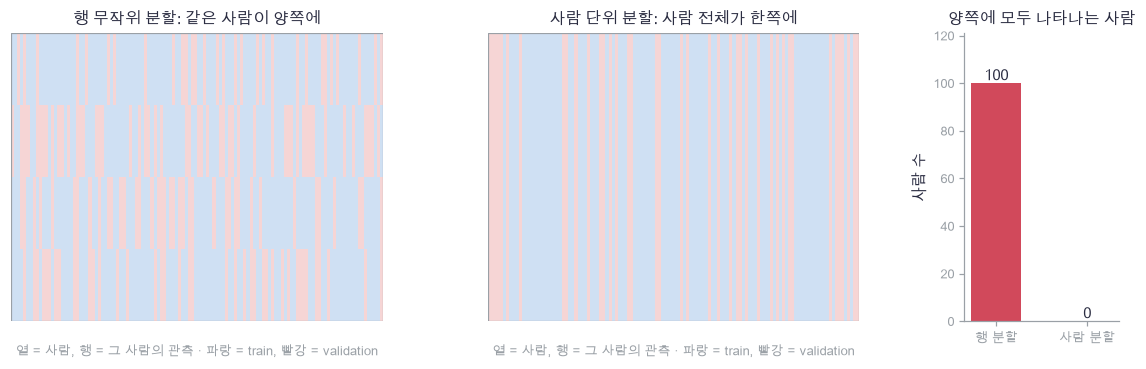

In [4]:
plot_split_units(demo_group_ids, demo_row_train, demo_group_train, 4, demo_overlaps)

🔍 **확인** · 왼쪽은 한 사람(열) 안에서 파랑과 빨강이 섞여 거의 모든 사람이 양쪽에 나타납니다. 오른쪽은 열 전체가 한 색이라 겹치는 사람이 0명입니다.
아래 기억 모델은 학습에서 본 사람의 평균 정답을 반환하고, 새 사람에게는 .5를 반환합니다. 두 분할에서 이 모델의 검증 정확도를 비교합니다.

In [5]:
def memorize_groups(train_groups, train_y, query_groups):
    """기억 모델: 학습에서 본 사람은 그 사람의 학습 정답 평균, 처음 보는 사람은 0.5. → query_groups와 같은 길이의 예측."""
    means = {group: train_y[train_groups == group].mean() for group in np.unique(train_groups)}   # 사람 → 정답 평균
    return np.array([means.get(group, .5) for group in query_groups])

In [6]:
# 쓰는 것: demo_row_train, demo_group_train (1절 그림 셀)
rng = np.random.default_rng(150)                            # 이 노트북의 검산용 난수 생성기. 3절도 이어 씁니다
group_ids = np.repeat(np.arange(120), 4)                    # (480,): 사람 ID
group_labels = np.tile([0, 1], 60)                          # (120,): 사람마다 정답
rng.shuffle(group_labels)
labels = group_labels[group_ids]                            # (480,): 행마다 그 사람의 정답
# 1. 행 무작위 분할: 같은 사람이 양쪽에 들어감
row_order = rng.permutation(len(labels))
row_train, row_valid = row_order[:320], row_order[320:]
row_predictions = memorize_groups(group_ids[row_train], labels[row_train], group_ids[row_valid])
row_accuracy = np.mean((row_predictions >= .5) == labels[row_valid])
# 2. 사람 단위 분할: 80명은 train, 40명은 validation
group_order = rng.permutation(120)
train_group_set, valid_group_set = group_order[:80], group_order[80:]
group_train = np.flatnonzero(np.isin(group_ids, train_group_set))    # train 사람들의 행 번호
group_valid = np.flatnonzero(np.isin(group_ids, valid_group_set))
assert len(np.intersect1d(group_ids[group_train], group_ids[group_valid])) == 0, "사람 단위 분할에서는 겹치는 사람이 없어야 합니다"
group_predictions = memorize_groups(group_ids[group_train], labels[group_train], group_ids[group_valid])
group_accuracy = np.mean((group_predictions >= .5) == labels[group_valid])
np.testing.assert_allclose(group_predictions, .5)           # 검산: 새 사람에게는 모두 0.5
np.testing.assert_allclose(group_accuracy, labels[group_valid].mean())   # 검산: 0.5 ≥ 0.5 → 전부 양성 판정 → 정확도 = 양성 비율
row_overlap = len(np.intersect1d(group_ids[row_train], group_ids[row_valid]))
print('행 분할 / 사람 분할 정확도:', row_accuracy, group_accuracy, '행 분할의 겹친 사람 수:', row_overlap)
np.testing.assert_array_equal(np.sort(row_train), np.flatnonzero(demo_row_train))              # 검산: 위 그림의 행 분할과 같음
np.testing.assert_array_equal(group_train, np.flatnonzero(demo_group_train))                   # 검산: 위 그림의 사람 분할과 같음

행 분할 / 사람 분할 정확도: 1.0 0.65 행 분할의 겹친 사람 수: 100


🔍 **확인** · 행 분할에서는 기억 모델이 높은 정확도를 얻지만, 사람 분할에서는 모든 새 사람에게 .5를 주므로 정확도가 검증 그룹의 양성 비율과 같습니다. 같은 모델, 같은 데이터인데 분할 단위가 점수를 바꿉니다.
사람 단위 점수는 새 사람에 대한 예측을 측정합니다. 같은 사람의 이후 방문을 예측하는 목적이라면 시간 순서와 당시 이용 가능한 정보까지 분할에 반영합니다.
이미지의 같은 원본에서 잘라낸 조각, 동일 문서의 문장, 같은 기기의 시계열도 평가 단위를 먼저 정합니다.

### ✏️ 연습 1 · 양쪽에 나타나는 사람 세기

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

사람 ID `group_ids` `(N,)`와 train 행 번호 `train_rows`, validation 행 번호 `valid_rows`가 있을 때, 두 집합에 함께 나타나는 사람 수 `overlap`을 내는 한 줄을 채우세요. 행 분할이면 이 수가 크고, 사람 단위 분할이면 0입니다. 이 연습은 분할을 만드는 쪽이 아니라, 주어진 분할에 누출이 있는지 세는 쪽입니다.

In [7]:
def exercise_group_overlap(group_ids, train_rows, valid_rows):
    """연습 1: 두 집합에 함께 나타나는 사람 수. group_ids: (N,) 사람 ID, train_rows·valid_rows: 행 번호 배열 → 겹친 사람 수 (정수)."""
    assert not np.any(np.isin(train_rows, valid_rows)), "같은 행이 양쪽에 있으면 안 됩니다 (행은 겹치지 않고 사람만 겹칠 수 있습니다)"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: train 행들의 사람 ID와 validation 행들의 사람 ID에 모두 있는 값의 개수 overlap
    ### 힌트: 1절 그림 셀의 demo_overlaps 한 항목입니다. group_ids[train_rows]로 그 행들의 사람 ID를 고르고, np.intersect1d로 공통 값을 모아 셉니다.
    raise NotImplementedError
    return overlap

In [8]:
def check_group_overlap(candidate):
    """사람 4명 × 관측 2개 손계산 둘과 1절 그림 셀의 480행 분할로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: demo_group_ids, demo_row_train, demo_group_train, demo_overlaps (1절 그림 셀)
    example_ids = np.repeat(np.arange(4), 2)                            # (8,): 사람 0, 0, 1, 1, 2, 2, 3, 3
    row_split = candidate(example_ids, np.array([0, 1, 2, 4, 6]), np.array([3, 5, 7]))
    assert row_split == 3, f"행 분할: train 사람 {{0, 1, 2, 3}}과 validation 사람 {{1, 2, 3}}이 겹쳐 3이어야 하는데 {row_split}입니다"
    group_split = candidate(example_ids, np.array([0, 1, 2, 3]), np.array([4, 5, 6, 7]))
    assert group_split == 0, f"사람 분할: train 사람 {{0, 1}}과 validation 사람 {{2, 3}}은 겹치지 않아 0이어야 하는데 {group_split}입니다"
    demo_row = candidate(demo_group_ids, np.flatnonzero(demo_row_train), np.flatnonzero(~demo_row_train))
    assert demo_row == demo_overlaps[0], f"1절 그림의 행 분할 겹침 수 {demo_overlaps[0]}과 같아야 하는데 {demo_row}입니다"
    demo_group = candidate(demo_group_ids, np.flatnonzero(demo_group_train), np.flatnonzero(~demo_group_train))
    assert demo_group == demo_overlaps[1], f"1절 그림의 사람 분할 겹침 수 {demo_overlaps[1]}과 같아야 하는데 {demo_group}입니다"
    print("겹친 사람 수: 손계산·1절 그림과 일치합니다.")

run_check(check_group_overlap, exercise_group_overlap, hint="overlap = len(np.intersect1d(group_ids[train_rows], group_ids[valid_rows]))")

☐ exercise_group_overlap: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: overlap = len(np.intersect1d(group_ids[train_rows], group_ids[valid_rows]))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
overlap = len(np.intersect1d(group_ids[train_rows], group_ids[valid_rows]))
```

</details>

## 🔑 2. 전처리도 학습 데이터에서 추정합니다

**이 절에서 가져갈 것:** 표준화의 평균·표준편차는 train에서만 구하고(`fit`), 같은 값을 validation·test에 적용합니다(`transform`). 미래 관측을 통계에 섞으면 학습에서 얻는 값이 달라지므로, 전처리 파라미터도 학습의 일부로 다룹니다.

> **용어** · **fit / transform**: 전처리 통계를 train에서 추정하는 단계와, 그 통계를 어떤 집합에든 적용하는 단계. PCA·특징 선택·어휘 사전도 같은 두 단계로 나눕니다.

학습 입력 $X_{train}:(N,D)$의 열별 평균·표준편차를 구해
$\tilde X=(X-\mu_{train})/s_{train}$로 변환합니다.
검증·test에는 같은 $\mu_{train},s_{train}$을 사용합니다. 상수 열의 표준편차는 1로 정해 중심화 값 0을 유지합니다.
이렇게 전처리 파라미터도 학습 과정의 일부로 취급합니다.

아래는 학습 관측 3개 `[1, 3, 5]`와 미래 관측 `100`의 첫 열입니다.

> **코드**
>
> - `np.append(std_train, std_future)`: 배열 끝에 값을 붙인 새 배열. "미래 관측을 섞은" 평균을 계산해 보려는 것입니다.
> - `np.where(scale < 1e-12, 1., scale)`: 표준편차가 0에 가까운 상수 열은 1로 바꿔 0 나눗셈을 막습니다.
> - `np.vstack([small_train, small_future])`: 행을 이어 붙임.

In [9]:
std_train = np.array([1., 3., 5.])                                    # (3,): 학습 관측의 첫 열
std_future = 100.                                                     # 미래 관측
std_mean, std_scale = std_train.mean(), std_train.std()                # 학습 통계: 3, √(8/3)
std_all_mean = np.append(std_train, std_future).mean()                 # 미래 관측을 섞으면 27.25
print("학습 평균", std_mean, "· 학습 표준편차", std_scale.round(4), "· 미래를 합친 평균", std_all_mean)

학습 평균 3.0 · 학습 표준편차 1.633 · 미래를 합친 평균 27.25


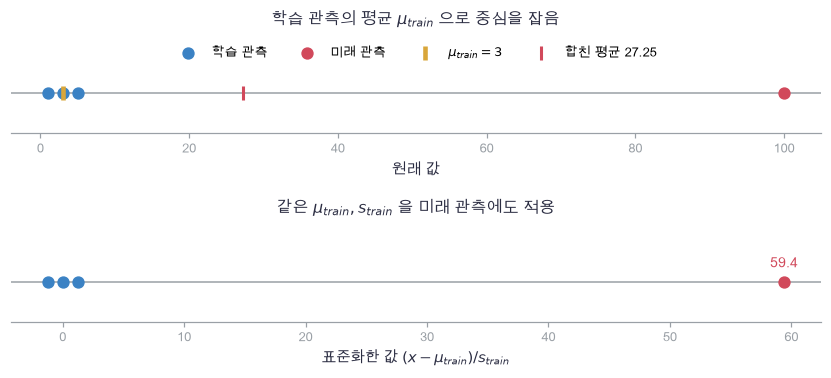

In [10]:
plot_standardize(std_train, std_future, std_mean, std_scale, std_all_mean)

🔍 **확인** · 학습 통계로 표준화하면 학습 관측은 $-1.22, 0, 1.22$가 되고 미래 관측 100은 59.4로 "매우 먼 값"으로 표시됩니다. 미래 관측을 평균에 섞으면 평균이 27.25로 옮겨 가 학습 관측 세 개가 모두 음수가 됩니다. 어느 쪽이 맞는지는 "무엇을 학습에 썼는가"가 정합니다.
아래 구현은 상수 열을 처리하는 `fit_standardizer`와 `transform`입니다.

In [11]:
def fit_standardizer(X):
    """표준화 통계를 학습 데이터에서 추정(fit): 열별 평균과 표준편차. 상수 열의 표준편차는 1. X: (N, D) → (mean: (D,), scale: (D,))."""
    mean = X.mean(axis=0)
    scale = X.std(axis=0)
    scale = np.where(scale < 1e-12, 1., scale)              # 상수 열: 0으로 나누지 않고 중심화만
    return mean, scale


def transform(X, mean, scale):
    """학습 통계로 표준화(transform): (X − μ_train)/s_train. 어떤 집합에든 같은 통계를 적용합니다."""
    return (X - mean) / scale

In [12]:
# 쓰는 것: std_mean, std_scale, std_all_mean (2절 그림 셀)
small_train = np.array([[1., 4.], [3., 4.], [5., 4.]])                # (3, 2): 둘째 열은 상수
small_future = np.array([[100., 4.]])                                 # (1, 2): 미래 관측
mean, scale = fit_standardizer(small_train)
np.testing.assert_allclose(mean, [3., 4.])                            # 검산: 열별 평균
np.testing.assert_allclose(transform(small_train, mean, scale).mean(axis=0), 0, atol=1e-14)   # 검산: 학습 관측을 변환하면 평균 0
np.testing.assert_allclose(transform(small_future, mean, scale), [[97/np.sqrt(8/3), 0.]])     # 검산: 미래 관측 (100 − 3)/√(8/3), 상수 열은 0
all_mean = np.vstack([small_train, small_future]).mean(axis=0)        # 미래 관측을 섞은 평균
assert not np.allclose(all_mean, mean), "미래 관측을 섞으면 평균이 달라져야 합니다"
print('학습 평균:', mean, '미래 관측을 합쳤을 때의 평균:', all_mean)
np.testing.assert_allclose((mean[0], scale[0], all_mean[0]), (std_mean, std_scale, std_all_mean))   # 검산: 위 그림의 값과 같음

학습 평균: [3. 4.] 미래 관측을 합쳤을 때의 평균: [27.25  4.  ]


🔍 **확인** · 학습 평균 $(3, 4)$로 변환한 학습 관측의 평균이 0이고, 미래 관측 `[100, 4]`는 $(59.4, 0)$입니다. 미래 관측을 합치면 학습에서 얻는 값이 달라집니다.
전처리 전체를 fit/transform으로 나누면 PCA, 특징 선택, 어휘 사전에도 같은 원칙을 적용할 수 있습니다.

### ✏️ 연습 2 · 같은 통계를 새 관측에도

학습 입력 `X_train` `(N, D)`에서 `fit_standardizer`로 구한 `mean`·`scale`은 미리 써 두었습니다. 그 같은 통계로 `X_train`과 새 관측 `X_new` `(M, D)`를 각각 변환한 `Z_train`, `Z_new`를 만드는 두 줄을 채우세요. 이 연습은 통계를 구하는 `fit`이 아니라, 구한 통계를 적용하는 `transform` 쪽입니다. `X_new`에서 새로 통계를 구하면 검사가 잡아냅니다.

In [13]:
def exercise_transform_with_train_stats(X_train, X_new):
    """연습 2: train에서 fit한 통계로 두 집합을 transform. X_train: (N, D), X_new: (M, D) → (Z_train: (N, D), Z_new: (M, D))."""
    assert X_train.shape[1] == X_new.shape[1], "두 집합의 열 수 D가 같아야 합니다"
    mean, scale = fit_standardizer(X_train)                  # (D,), (D,): 통계는 train에서만 (2절 fit)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 같은 mean·scale로 X_train을 변환한 Z_train과 X_new를 변환한 Z_new
    ### 힌트: 2절 transform 본문 (X − μ_train)/s_train을 두 집합에 한 번씩 씁니다. X_new의 평균·표준편차는 어디에도 쓰지 않습니다.
    raise NotImplementedError
    return Z_train, Z_new

In [14]:
def check_transform_with_train_stats(candidate):
    """2절 손계산(학습 관측 3개 · 상수 열)과 미래 관측 2개로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: fit_standardizer, transform (2절)
    example_train = np.array([[1., 4.], [3., 4.], [5., 4.]])            # (3, 2): 첫 열 1, 3, 5 · 둘째 열은 상수
    example_new = np.array([[100., 4.], [3., 9.]])                       # (2, 2): 미래 관측
    Z_train, Z_new = candidate(example_train, example_new)
    assert Z_train.shape == (3, 2), f"Z_train은 (3, 2)여야 하는데 {Z_train.shape}입니다"
    assert Z_new.shape == (2, 2), f"Z_new는 (2, 2)여야 하는데 {Z_new.shape}입니다"
    np.testing.assert_allclose(Z_train, [[-np.sqrt(1.5), 0.], [0., 0.], [np.sqrt(1.5), 0.]])   # 검산: (1−3)/√(8/3) = −1.22, 상수 열은 0
    np.testing.assert_allclose(Z_new, [[97 / np.sqrt(8 / 3), 0.], [0., 5.]])                  # 검산: 미래 관측 100은 59.4, 9는 (9−4)/1 = 5
    assert not np.allclose(Z_new.mean(axis=0), 0.), "X_new 자신의 평균으로 표준화하면 안 됩니다 (Z_new의 열 평균이 0이면 틀린 통계입니다)"
    np.testing.assert_allclose(Z_new, transform(example_new, *fit_standardizer(example_train)))   # 검산: 2절 fit_standardizer·transform과 같음
    print("train 통계로 transform: 손계산과 일치합니다.")

run_check(check_transform_with_train_stats, exercise_transform_with_train_stats, hint="Z_train = (X_train - mean) / scale; Z_new = (X_new - mean) / scale")

☐ exercise_transform_with_train_stats: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z_train = (X_train - mean) / scale; Z_new = (X_new - mean) / scale


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z_train = (X_train - mean) / scale
Z_new = (X_new - mean) / scale
```

</details>

## 🔍 3. 작은 데이터에서 전체 학습 경로 검산하기

로지스틱 회귀 $z=Xw+b$, $p=\sigma(z)$,
$J=\operatorname{mean}[\log(1+e^z)-yz]+\lambda\|w\|^2/2$를 사용합니다.
$g=(p-y)/N$이면 $dw=X^Tg+\lambda w$, $db=\sum_ng_n$입니다.
`logaddexp(0,z)`는 큰 $z$에서도 안정적으로 $\log(1+e^z)$를 계산합니다.

매 epoch에서 모든 학습 관측을 한 번씩 사용합니다. 마지막 작은 배치에도 그 배치의 관측 수로 평균을 냅니다.
기록은 epoch 끝의 **같은 파라미터**로 전체 train·validation을 평가합니다.
기록할 값은 데이터 BCE, 정규화 포함 목적, 전체 기울기 norm, 해당 epoch의 업데이트 norm 합입니다.

> **용어** · **checkpoint**: epoch마다 저장한 파라미터 복사본. 검증 BCE가 가장 작은 epoch의 것을 고릅니다.

> **코드**
>
> - `np.exp(-np.logaddexp(0., -z))`: σ(z) = 1/(1 + e^−z) = exp(−log(1 + e^−z)). 큰 |z|에서도 넘치지 않는 sigmoid입니다.
> - `def train_logistic(X, y, X_valid, y_valid, *, l2=0., …)`: 별표 뒤의 인자는 이름을 붙여서만 넘깁니다(`l2=.02`처럼).
> - `indices[start:start+batch_size]`: 섞은 번호를 앞에서부터 배치 크기씩 자름(01b 3절). 마지막 배치는 짧을 수 있습니다.
> - `snapshots.append((w.copy(), float(b)))`: epoch마다 파라미터 복사본(checkpoint)을 보관. `history[:, 1]`은 기록 표의 둘째 열(검증 BCE).
> - 함수가 사전 `{'w': …, 'epoch': …}`을 돌려주면 `run['epoch']`처럼 이름으로 꺼냅니다.

In [15]:
def sigmoid(z):
    """σ(z) = 1/(1 + e^−z)를 exp(−logaddexp(0, −z))로 안정하게. z: 어떤 모양 → 같은 모양."""
    return np.exp(-np.logaddexp(0., -z))


def logistic_objective(X, y, w, b, l2=0.):
    """로지스틱 회귀의 목적과 기울기: J = mean[log(1 + e^z) − yz] + (λ/2)‖w‖², g = (σ(z) − y)/N, dw = Xᵀg + λw, db = Σg.
    X: (N, D), y: (N,), w: (D,), b: 숫자 → (J, 데이터 BCE, dw: (D,), db: 숫자)."""
    logits = X @ w + b                                      # (N,)
    data_loss = np.mean(np.logaddexp(0., logits) - y*logits)   # 평균 BCE (02번 7절)
    g = (sigmoid(logits) - y) / len(y)                      # (N,): logit 기울기 (평균 포함)
    return data_loss + .5*l2*np.sum(w*w), data_loss, X.T @ g + l2*w, g.sum()

In [16]:
def train_logistic(X, y, X_valid, y_valid, *, l2=0., epochs=120, batch_size=64, lr=.08, seed=1):
    """미니배치 SGD로 epochs번 학습하며 epoch마다 train·validation을 같은 파라미터로 기록하고, 검증 BCE가 가장 작은 epoch의 checkpoint를 고릅니다.
    → {'w', 'b', 'epoch'(1부터), 'history' (epochs, 5): [train BCE, valid BCE, 목적, 전체 기울기 norm, 업데이트 norm 합], 'validation_bce'}."""
    local_rng = np.random.default_rng(seed)                 # seed가 초기값과 배치 순서를 정함
    w, b = local_rng.normal(size=X.shape[1]) * .05, 0.
    history = []
    snapshots = []
    for epoch in range(epochs):
        indices = local_rng.permutation(len(y))             # 1. 에폭마다 섞기
        update_norm_sum = 0.
        for start in range(0, len(y), batch_size):          # 2. 배치마다 갱신 (마지막 배치도 그 크기로 평균)
            batch = indices[start:start+batch_size]
            _, _, dw, db = logistic_objective(X[batch], y[batch], w, b, l2)
            update_norm_sum += lr*np.sqrt(np.sum(dw**2)+db**2)   # 이 갱신의 크기
            w -= lr*dw
            b -= lr*db
        objective, train_bce, dw, db = logistic_objective(X, y, w, b, l2)   # 3. epoch 끝의 같은 파라미터로 전체 평가
        valid_bce = logistic_objective(X_valid, y_valid, w, b)[1]
        history.append([train_bce, valid_bce, objective, np.sqrt(np.sum(dw**2)+db**2), update_norm_sum])
        snapshots.append((w.copy(), float(b)))              # checkpoint
    history = np.asarray(history)
    best_epoch = int(np.argmin(history[:, 1]))              # 4. 검증 BCE가 가장 작은 epoch
    return {'w': snapshots[best_epoch][0], 'b': snapshots[best_epoch][1],
            'epoch': best_epoch+1, 'history': history, 'validation_bce': history[best_epoch, 1]}

In [17]:
# 쓰는 것: rng (1절 검산 셀)
X_check, y_check = rng.normal(size=(7, 3)), np.array([0., 1., 0., 1., 1., 0., 0.])   # (N, D), (N,)
w_check, b_check = rng.normal(size=3), np.array(.3)          # (3,), 스칼라 배열
_, _, dw, db = logistic_objective(X_check, y_check, w_check, b_check, l2=.2)


def objective_scalar():
    """검사기용: 목적값 J."""
    return logistic_objective(X_check, y_check, w_check, b_check, l2=.2)[0]


check_errors = [rel_error(analytic, numerical_gradient(objective_scalar, parameter))
                for analytic, parameter in [(dw, w_check), (np.array(db), b_check)]]   # dw, db를 중심차분과 대조
assert max(check_errors) < 1e-7, "dw, db의 상대오차가 1e−7 아래여야 합니다"
X_tiny = np.array([[-2., -1.], [-1., -2.], [1., 2.], [2., 1.]])   # (4, 2): 선형 분리 가능한 네 관측
y_tiny = np.array([0., 0., 1., 1.])
tiny = train_logistic(X_tiny, y_tiny, X_tiny, y_tiny, epochs=400, batch_size=4)   # 같은 네 관측을 모니터링에 (구현 점검)
tiny_prediction = sigmoid(X_tiny @ tiny['w'] + tiny['b'])
assert np.mean((tiny_prediction >= .5) == y_tiny) == 1., "네 관측을 모두 맞혀야 합니다"
assert tiny['validation_bce'] < .01, "네 관측의 BCE가 0.01 아래로 내려가야 합니다"
print('수치미분 최대 상대 오차:', max(check_errors), '네 관측 BCE:', tiny['validation_bce'])

수치미분 최대 상대 오차: 1.2192836497133915e-09 네 관측 BCE: 0.007067326729228688


🔍 **확인** · 기울기가 중심차분과 맞고, 네 관측에서 손실이 0.01 아래로 내려갑니다. 네 관측에서 손실이 줄어들면 순전파·라벨·역전파·갱신의 연결을 먼저 확인할 수 있습니다.
여기서는 같은 네 관측을 모니터링에 사용한 구현 점검입니다. 다음 실험에서 별도의 검증·test 관측을 사용합니다.

## 🔑 4. 설정과 epoch는 검증에서 선택합니다

**이 절에서 가져갈 것:** $\lambda$와 epoch처럼 학습으로 정해지지 않는 선택은 validation의 점수로 고릅니다. seed마다 검증 BCE가 가장 작은 epoch의 checkpoint를 두고, seed 평균으로 $\lambda$를 고릅니다. 같은 seed는 같은 초기값·배치 순서라 조건 사이 비교를 짝지어 줍니다.

> **용어** · **seed**: 초기값·배치 순서 같은 무작위성을 재현하는 번호. 조건을 바꿀 때 seed를 맞추면 무작위성의 차이가 아니라 조건의 차이를 봅니다.

서로 독립인 관측 900개를 만들고 train 540개, validation 180개, test 180개로 고정합니다.
데이터 생성 seed 151과 분할 seed 152를 별도로 고정합니다. 입력 8개 중 앞의 두 좌표가 라벨 확률을 결정하며, 나머지는 무관한 잡음 좌표입니다.
라벨은 Bernoulli 샘플이므로 입력만으로 정답을 완벽히 맞히기 어려운 관측도 있습니다.

$\lambda\in\{0,.02,.2\}$와 seed 3개를 사용합니다.
각 실행에서 검증 BCE가 가장 작은 epoch의 복사본을 고르고, seed 평균 검증 BCE로 $\lambda$를 선택합니다.
동일 seed는 같은 초기값·배치 순서를 사용해 조건 사이 비교를 짝지어 줍니다.

> **코드**
>
> - `(data_rng.random(900) < sigmoid(true_logits)).astype(float)`: 확률 σ(z)로 1이 나오는 Bernoulli 샘플. 균등 난수가 확률보다 작으면 1.
> - `set(train_index) & set(valid_index)`: 두 집합의 교집합. 비어 있으면 겹치는 관측이 없습니다.
> - `{l2: [train_logistic(…, seed=seed) for seed in seeds] for l2 in l2_values}`: λ마다 seed별 실행 결과 목록을 담은 사전.
> - `min(mean_validation, key=mean_validation.get)`: 사전에서 값이 가장 작은 키(λ).

In [18]:
# 쓰는 것: fit_standardizer, transform (2절) · sigmoid, train_logistic (3절)
# 1. 데이터: 특성 8개 (앞 둘만 라벨에 관여), 라벨은 Bernoulli 샘플
data_rng = np.random.default_rng(151)
split_rng = np.random.default_rng(152)
raw_X = data_rng.normal(size=(900, 8)) * np.array([3., .5, 2., 1., .2, 4., 1., 2.]) + np.arange(8)   # (900, 8): 열마다 퍼짐·중심이 다름
true_logits = 1.2*(raw_X[:, 0]/3) - 1.5*((raw_X[:, 1]-1)/.5) - 1.2                                 # (900,): 참 logit (앞 두 좌표만)
raw_y = (data_rng.random(900) < sigmoid(true_logits)).astype(float)                                # (900,): Bernoulli 라벨
# 2. 분할: 540 / 180 / 180 (겹침 없음)
order = split_rng.permutation(900)
train_index, valid_index, test_index = order[:540], order[540:720], order[720:]
assert len(set(train_index) & set(valid_index)) == 0, "train과 validation이 겹치면 안 됩니다"
assert len(set(train_index) & set(test_index)) == 0, "train과 test가 겹치면 안 됩니다"
assert len(set(valid_index) & set(test_index)) == 0, "validation과 test가 겹치면 안 됩니다"
# 3. 전처리는 train에서 fit, 나머지에 transform
train_mean, train_scale = fit_standardizer(raw_X[train_index])
X_train, X_valid = transform(raw_X[train_index], train_mean, train_scale), transform(raw_X[valid_index], train_mean, train_scale)
y_train, y_valid = raw_y[train_index], raw_y[valid_index]
# 4. λ × seed 실행, seed 평균 검증 BCE로 λ 선택
seeds, l2_values = [1, 2, 3], [0., .02, .2]
runs = {l2: [train_logistic(X_train, y_train, X_valid, y_valid, l2=l2, seed=seed) for seed in seeds] for l2 in l2_values}   # λ → seed별 결과
mean_validation = {l2: np.mean([run['validation_bce'] for run in group]) for l2, group in runs.items()}   # λ → seed 평균
selected_l2 = min(mean_validation, key=mean_validation.get)
selected_runs = runs[selected_l2]                           # 선택한 λ의 seed 3개 실행
print('train/validation 관측 수:', len(y_train), len(y_valid), '양성 비율:', y_train.mean(), y_valid.mean())
print('lambda별 평균 검증 BCE:', mean_validation, '선택 lambda:', selected_l2)
print('선택 epoch:', [run['epoch'] for run in selected_runs])

train/validation 관측 수: 540 180 양성 비율: 0.34814814814814815 0.32222222222222224
lambda별 평균 검증 BCE: {0.0: np.float64(0.4430584554376771), 0.02: np.float64(0.4456812462931811), 0.2: np.float64(0.5036214279992529)} 선택 lambda: 0.0
선택 epoch: [89, 58, 48]


In [19]:
selection_table = np.array([[run["validation_bce"] for run in runs[l2]] for l2 in l2_values])   # (λ 3, seed 3): 검증 BCE 표
selection_means = selection_table.mean(axis=1)                                                  # (3,): seed 평균
np.testing.assert_allclose(selection_means, [mean_validation[l2] for l2 in l2_values])          # 검산: 위 셀의 λ별 평균과 같음
print("λ × seed 검증 BCE\n", selection_table.round(4), "\nseed 평균", selection_means.round(4))

λ × seed 검증 BCE
 [[0.4435 0.4429 0.4428]
 [0.4457 0.4456 0.4458]
 [0.5038 0.5037 0.5033]] 
seed 평균 [0.4431 0.4457 0.5036]


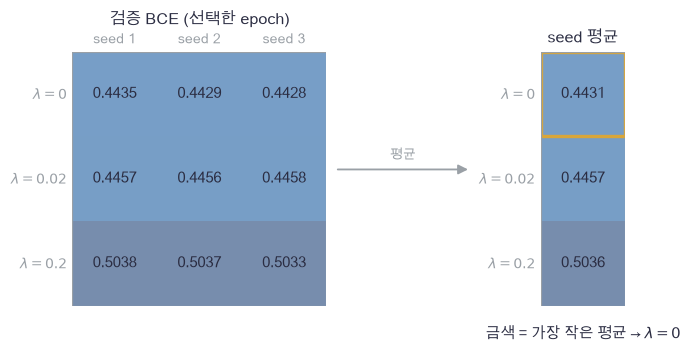

In [20]:
plot_selection_table(l2_values, seeds, selection_table, selection_means, selected_l2)

🔍 **확인** · 같은 $\lambda$ 안에서도 seed마다 검증 BCE가 조금씩 다릅니다. 한 seed의 한 숫자로 $\lambda$를 고르면 그 차이가 무작위성인지 조건의 효과인지 알 수 없어, 같은 seed끼리 짝지어 평균으로 고릅니다.
아래는 선택한 $\lambda$의 첫 seed에서 epoch마다 기록한 곡선입니다.

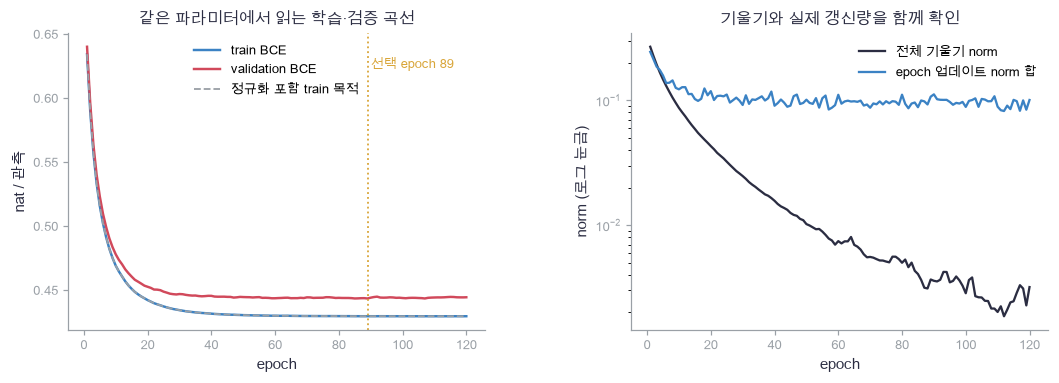

In [21]:
history = selected_runs[0]['history']                       # (120, 5): 선택한 λ의 첫 seed 기록
epochs = np.arange(1, len(history)+1)
plot_training_curves(epochs, history, selected_runs[0]["epoch"])

🔍 **확인** · 검증 곡선의 최소 위치(금색)에서 파라미터를 저장했습니다. 전체 epoch 수는 정해 두고 그 범위 안의 checkpoint를 선택하는 방식입니다.
업데이트 norm의 합은 미니배치 순서와 학습률에 영향을 받습니다. train 전체 기울기 norm과 각각의 의미를 읽습니다.

### ✏️ 연습 4 · seed 평균으로 λ 고르기

검증 BCE 표 `validation_table` `(L, S)`는 행이 $\lambda$ 후보, 열이 seed입니다. 행마다 seed 축을 평균낸 `seed_means` `(L,)`과, 그 평균이 가장 작은 행의 $\lambda$ 값 `selected`를 만드는 두 줄을 채우세요. 검사 표는 seed 하나만 보면 다른 $\lambda$가 골라지도록 만들어 두었습니다.

In [22]:
def exercise_select_l2(validation_table, l2_values):
    """연습 4: seed 평균 검증 BCE로 λ 선택. validation_table: (λ 후보 L, seed S), l2_values: 길이 L 목록 → (seed_means: (L,), selected: λ 값 하나)."""
    validation_table = np.asarray(validation_table)
    assert validation_table.shape[0] == len(l2_values), "표의 행 수는 λ 후보 수 L과 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 행마다 seed 축을 평균낸 seed_means (L,)과, 그 평균이 가장 작은 행의 λ 값 selected
    ### 힌트: 4절 표 셀의 selection_table.mean(axis=…)과 np.argmin입니다. l2_values[행 번호]로 λ 값을 꺼냅니다.
    raise NotImplementedError
    return seed_means, selected

In [23]:
def check_select_l2(candidate):
    """λ 3개 × seed 3개 손계산 표 하나와 4절 실험의 표로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: selection_table, selection_means (4절 표 셀) · l2_values, selected_l2 (4절 실험 셀)
    example_table = np.array([[.55, .66, .68], [.60, .60, .60], [.62, .59, .70]])   # (3, 3): 행 = λ, 열 = seed
    example_l2 = [0., .02, .2]
    seed_means, selected = candidate(example_table, example_l2)
    assert np.shape(seed_means) == (3,), f"seed 평균은 λ마다 하나, (3,)이어야 하는데 {np.shape(seed_means)}입니다"
    np.testing.assert_allclose(seed_means, [.63, .60, .63 + 1 / 150])      # 검산: 행 평균 [1.89/3, 1.80/3, 1.91/3]
    assert selected == .02, f"평균이 가장 작은 둘째 행의 λ = 0.02를 골라야 하는데 {selected}입니다"
    only_first_seed = candidate(example_table[:, :1], example_l2)[1]       # seed 열 하나만 넘긴 경우
    assert only_first_seed == 0., f"첫 seed 하나만 보면 λ = 0이 골라집니다 (그래서 seed 평균으로 고릅니다). 지금은 {only_first_seed}입니다"
    means_b, selected_b = candidate(selection_table, l2_values)
    np.testing.assert_allclose(means_b, selection_means)                   # 검산: 4절 표 셀의 seed 평균과 같음
    assert selected_b == selected_l2, f"4절 실험이 고른 λ = {selected_l2}와 같아야 하는데 {selected_b}입니다"
    print("seed 평균으로 λ 선택: 손계산·4절 실험과 일치합니다.")

run_check(check_select_l2, exercise_select_l2, hint="seed_means = validation_table.mean(axis=1); selected = l2_values[np.argmin(seed_means)]")

☐ exercise_select_l2: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: seed_means = validation_table.mean(axis=1); selected = l2_values[np.argmin(seed_means)]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
seed_means = validation_table.mean(axis=1)
selected = l2_values[np.argmin(seed_means)]
```

</details>

## 🔑 5. 분류와 확률을 다른 지표로 읽기

**이 절에서 가져갈 것:** 임계값으로 판정하면 TP·FP·TN·FN 네 칸이 생기고 accuracy·precision·recall·F1은 그 칸의 비율입니다. AUC는 임계값 없이 양성이 음성보다 높은 점수를 받는 비율(순위), NLL·Brier는 확률 자체의 정확도를 잽니다. 한 숫자가 모든 성질을 말하지 않습니다.

> **용어**
>
> - **혼동 행렬(confusion matrix)** `[[TN, FP], [FN, TP]]`: 정답(행)과 예측(열)의 네 조합 개수. accuracy는 대각선의 비율, precision은 예측 양성 중 맞은 비율, recall은 실제 양성 중 잡은 비율.
> - **ROC-AUC**: 무작위 양성의 점수가 무작위 음성보다 높을 확률(동점은 절반). 임계값과 무관한 순위 지표.
> - **Brier·NLL**: 확률과 정답의 제곱 차이 평균, 정답에 준 확률의 음의 로그 평균. 확률이 얼마나 정확한지를 잽니다.

임계값 $t$에서 $\hat y=1[p\ge t]$로 정합니다. TP·FP·TN·FN은 정답과 예측의 네 조합입니다.
precision은 $TP/(TP+FP)$, recall은 $TP/(TP+FN)$, F1은 $2TP/(2TP+FP+FN)$입니다.
이 실습에서는 분모가 0인 precision·recall·F1 값을 0으로 정합니다.

- **accuracy:** 정답 비율. 양성 비율이 낮으면 음성만 예측해도 큰 값이 될 수 있습니다.
- **BCE/NLL:** 실제 정답에 준 확률의 음의 로그 평균. 틀린 확신에 큰 비용을 줍니다.
- **Brier:** $\operatorname{mean}(p-y)^2$. 예측 확률과 관측의 제곱 차이입니다.
- **ROC-AUC:** 무작위 양성의 점수가 무작위 음성보다 높을 확률에 동점 확률의 절반을 더한 값입니다. 아래에서는 모든 양성·음성 쌍을 직접 비교합니다. 두 클래스가 모두 있을 때 계산합니다. 한 클래스만 관측되면 이 구현은 `np.nan`으로 그 조건을 표시합니다.

AUC는 순위, 임계값 지표는 결정, NLL·Brier는 확률 예측을 평가합니다.

아래는 관측 4개 `y = [0, 0, 1, 1]`, `p = [.1, .8, .4, .9]`의 손계산입니다.

> **코드**
>
> - `hm_p[hm_y == 1][:, None] - hm_p[hm_y == 0][None, :]`: 양성 점수 `(P, 1)`에서 음성 점수 `(1, Q)`를 빼 모든 쌍의 차 `(P, Q)`. `np.mean((차 > 0) + .5 * (차 == 0))`이 AUC.
> - `np.where(y == 1, p, 1 - p)`: 정답에 준 확률. 그 −log의 평균이 NLL.
> - `tp/(tp+fp) if tp+fp else 0.`: 분모가 0이면 0으로 두는 조건식.
> - `np.isin(y, [0, 1])`: 값이 0 또는 1인지. `{k: round(float(v), 4) for k, v in d.items()}`: 사전의 값만 반올림한 새 사전.

In [24]:
hm_y, hm_p, hm_t = np.array([0, 0, 1, 1]), np.array([.1, .8, .4, .9]), .5   # 정답, 확률, 임계값
hm_pred = hm_p >= hm_t                                                # (4,): 양성 판정
hm_tp, hm_fp = np.sum((hm_y == 1) & hm_pred), np.sum((hm_y == 0) & hm_pred)      # 맞힌 양성, 잘못 잡은 음성
hm_tn, hm_fn = np.sum((hm_y == 0) & ~hm_pred), np.sum((hm_y == 1) & ~hm_pred)    # 맞힌 음성, 놓친 양성
hm_confusion = np.array([[hm_tn, hm_fp], [hm_fn, hm_tp]])             # (2, 2): 행 = 정답, 열 = 예측
hm_diff = hm_p[hm_y == 1][:, None] - hm_p[hm_y == 0][None, :]          # (2, 2): 양성·음성 모든 쌍의 점수 차
hm_metrics = {"accuracy": (hm_tp + hm_tn) / 4, "precision": hm_tp / (hm_tp + hm_fp), "recall": hm_tp / (hm_tp + hm_fn),
              "f1": 2 * hm_tp / (2 * hm_tp + hm_fp + hm_fn), "auc": np.mean((hm_diff > 0) + .5 * (hm_diff == 0)),
              "brier": np.mean((hm_p - hm_y) ** 2), "nll": -np.mean(np.log(np.where(hm_y == 1, hm_p, 1 - hm_p)))}
print("혼동 행렬\n", hm_confusion, "\n", {k: round(float(v), 4) for k, v in hm_metrics.items()})

혼동 행렬
 [[1 1]
 [1 1]] 
 {'accuracy': 0.5, 'precision': 0.5, 'recall': 0.5, 'f1': 0.5, 'auc': 0.75, 'brier': 0.255, 'nll': 0.6841}


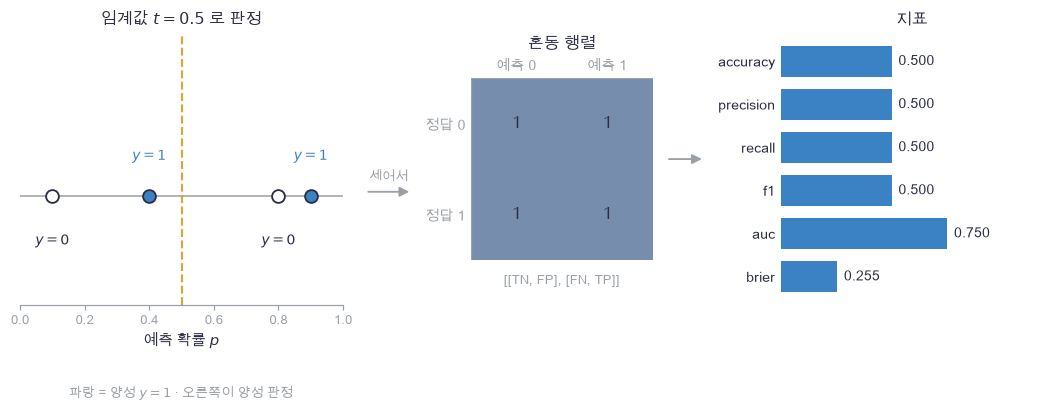

In [25]:
plot_metrics_hand(hm_y, hm_p, hm_t, hm_confusion, hm_metrics)

🔍 **확인** · 임계값 .5 오른쪽의 양성 판정 두 개 중 하나만 정답이라 precision .5, 실제 양성 둘 중 하나만 잡아 recall .5입니다. AUC .75는 양성·음성 네 쌍 중 세 쌍에서 양성 점수가 더 높다는 뜻이고, Brier .255는 확률 자체의 오차입니다.
아래 구현은 입력 검사와 분모 0 규약을 포함한 `binary_metrics`입니다.

In [26]:
def binary_metrics(y, p, threshold=.5):
    """이진 분류 지표 한 번에: 임계값 판정의 혼동 행렬과 accuracy·precision·recall·F1(분모 0은 0), 확률 지표 NLL·Brier, 순위 지표 AUC(한 클래스뿐이면 nan).
    y: (N,) 0/1, p: (N,) 확률 → 사전."""
    y, p = np.asarray(y), np.asarray(p)
    if y.ndim != 1 or p.shape != y.shape or len(y) == 0:
        raise ValueError('y와 p는 같은 길이의 1차원 배열입니다.')
    if not np.all(np.isin(y, [0, 1])) or np.any(~np.isfinite(p)) or np.any((p < 0) | (p > 1)):
        raise ValueError('y는 0/1이며 p는 [0,1]의 유한한 확률입니다.')
    prediction = p >= threshold                             # (N,): 양성 판정
    tp = np.sum((y == 1) & prediction)                      # 네 칸
    fp = np.sum((y == 0) & prediction)
    tn = np.sum((y == 0) & ~prediction)
    fn = np.sum((y == 1) & ~prediction)
    correct_probability = np.where(y == 1, p, 1-p)          # (N,): 정답에 준 확률
    nll = np.inf if np.any(correct_probability == 0) else -np.log(correct_probability).mean()
    positives, negatives = p[y == 1], p[y == 0]
    auc = np.nan
    if len(positives) and len(negatives):                   # 두 클래스가 모두 있을 때만
        differences = positives[:, None] - negatives[None, :]   # (P, Q): 모든 쌍
        auc = np.mean((differences > 0) + .5*(differences == 0))   # 동점은 절반
    return {'accuracy': (tp+tn)/len(y), 'precision': tp/(tp+fp) if tp+fp else 0.,
            'recall': tp/(tp+fn) if tp+fn else 0., 'f1': 2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0.,
            'nll': nll, 'brier': np.mean((p-y)**2), 'auc': auc,
            'confusion': np.array([[tn, fp], [fn, tp]])}

In [27]:
# 쓰는 것: hm_metrics (5절 손계산 셀)
hand_y, hand_p = np.array([0, 0, 1, 1]), np.array([.1, .8, .4, .9])
hand_metrics = binary_metrics(hand_y, hand_p)
np.testing.assert_array_equal(hand_metrics['confusion'], [[1, 1], [1, 1]])   # 검산: 네 칸이 하나씩
for name in ['accuracy', 'precision', 'recall', 'f1']:
    np.testing.assert_allclose(hand_metrics[name], .5)      # 검산: 임계값 지표 넷 모두 0.5
np.testing.assert_allclose(hand_metrics['auc'], .75)        # 검산: 네 쌍 중 세 쌍
np.testing.assert_allclose(hand_metrics['brier'], .255)     # 검산: 제곱 차의 평균
np.testing.assert_allclose(binary_metrics([0, 1], [.5, .5])['auc'], .5)   # 검산: 동점은 0.5
assert np.isinf(binary_metrics([0, 1], [1., 0.])['nll']), "확률 0·1로 틀리면 NLL은 무한대여야 합니다"
print('네 관측 손계산:', {k:v for k,v in hand_metrics.items() if k != 'confusion'})
for key in ("accuracy", "precision", "recall", "f1", "auc", "brier", "nll"):
    np.testing.assert_allclose(hand_metrics[key], hm_metrics[key])    # 검산: 위 그림의 손계산과 같음

네 관측 손계산: {'accuracy': np.float64(0.5), 'precision': np.float64(0.5), 'recall': np.float64(0.5), 'f1': np.float64(0.5), 'nll': np.float64(0.6841124189059771), 'brier': np.float64(0.25500000000000006), 'auc': np.float64(0.75)}


🔍 **확인** · 손계산 네 값과 AUC .75·Brier .255가 맞고, 동점 확률은 AUC .5, 확률 0·1로 틀리면 NLL이 무한대입니다.

### 🔍 같은 지표를 MNIST 7 판별에서 보면

00번의 7 템플릿으로 5,000장의 점수를 내고 0을 기준으로 "7인가"를 판정합니다. 확률은 점수의 sigmoid로 두어 임계값 .5가 점수 0과 같게 합니다.

In [28]:
# 쓰는 것: mnist_X, mnist_y, mnist_T, template_7 (📎 데이터 셀)
mnist_scores = mnist_X @ template_7                                   # (5000,): 템플릿 점수
mnist_p = 1 / (1 + np.exp(-0.4 * mnist_scores))                      # (5000,): 확률로. 점수 0 ↔ 확률 .5
mnist_metrics = binary_metrics(mnist_T, mnist_p)
fp_index = np.flatnonzero((mnist_T == 0) & (mnist_p >= .5))[:3]      # 7이 아닌데 7이라 한 것 (앞 3개)
fn_index = np.flatnonzero((mnist_T == 1) & (mnist_p < .5))[:3]       # 7인데 놓친 것
wrong_images = [mnist_X[i].reshape(28, 28) for i in np.concatenate([fp_index, fn_index])]   # 그림용
wrong_titles = [f"FP: 정답 {mnist_y[i]}" for i in fp_index] + [f"FN: 정답 {mnist_y[i]}" for i in fn_index]
print({k: round(float(v), 3) for k, v in mnist_metrics.items() if k != "confusion"})

{'accuracy': 0.869, 'precision': 0.453, 'recall': 0.945, 'f1': 0.613, 'nll': 0.296, 'brier': 0.092, 'auc': 0.976}


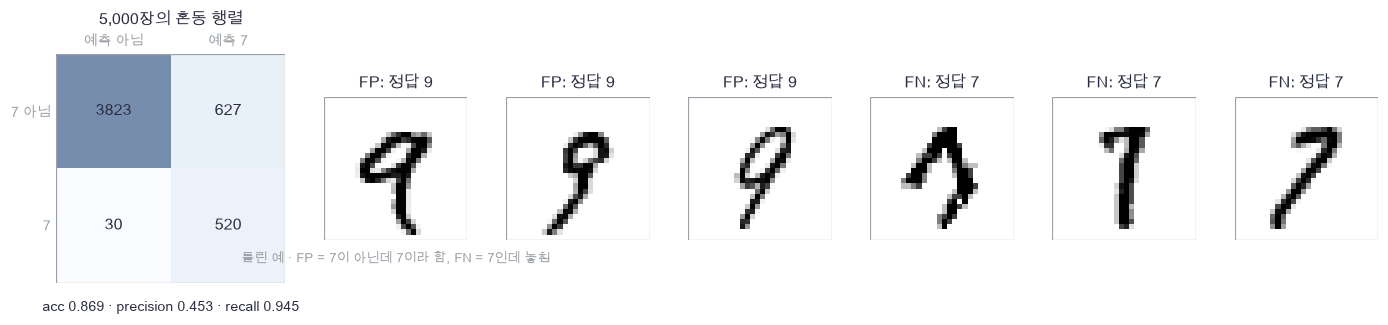

In [29]:
plot_confusion_examples(mnist_metrics["confusion"], wrong_images, wrong_titles, mnist_metrics["accuracy"], mnist_metrics["precision"], mnist_metrics["recall"])

🔍 **확인** · 7은 10%뿐이라 accuracy는 높아 보이지만, 예측 양성 중 실제 7의 비율(precision)은 훨씬 낮습니다. FP는 9·2처럼 윗획이 있는 숫자, FN은 흐리거나 기울어진 7입니다. 불균형에서는 accuracy 하나로 모델을 읽지 않습니다.

### 🔍 정확도는 같아도 확신의 정도는 달라집니다

선택한 첫 실행의 검증 logits를 3배하면 0의 어느 쪽인지는 그대로이고 확률은 0·1에 가까워집니다.
임계값 .5의 정확도는 같지만 NLL·Brier는 달라질 수 있습니다.
아래 비교는 **검증 관측에서 확률 지표를 읽는 실험**입니다.

In [30]:
# 쓰는 것: selected_runs, X_valid, y_valid (4절 실험 셀) · sigmoid (3절) · binary_metrics (5절)
reference_run = selected_runs[0]                            # 선택한 λ의 첫 seed 실행
validation_logits = X_valid @ reference_run['w'] + reference_run['b']   # (180,)
validation_p = sigmoid(validation_logits)
sharp_p = sigmoid(3*validation_logits)                      # logit 3배: 판정은 같고 확률만 0·1 쪽으로
ordinary_metrics, sharp_metrics = binary_metrics(y_valid, validation_p), binary_metrics(y_valid, sharp_p)
assert ordinary_metrics['accuracy'] == sharp_metrics['accuracy'], "logit을 양수배 해도 임계값 .5의 정확도는 같아야 합니다"
print('원래 확률 accuracy/NLL/Brier:', ordinary_metrics['accuracy'], ordinary_metrics['nll'], ordinary_metrics['brier'])
print('logit 3배 accuracy/NLL/Brier:', sharp_metrics['accuracy'], sharp_metrics['nll'], sharp_metrics['brier'])

원래 확률 accuracy/NLL/Brier: 0.8055555555555556 0.4434677231510092 0.14124827418324257
logit 3배 accuracy/NLL/Brier: 0.8055555555555556 0.7084902535875643 0.15887218330438366


🔍 **확인** · logit을 3배 해도 accuracy는 같지만 NLL·Brier가 달라집니다. 확률 지표는 "얼마나 확신했는가"까지 읽습니다.

### 🔍 calibration: 확률이 실제 비율과 맞는가

> **용어** · **calibration·ECE**: 예측 확률 .7 부근의 관측 중 실제 양성이 약 70%면 그 구간은 잘 맞는 것. ECE는 구간별 |확률 평균 − 양성 비율|을 구간 크기로 가중 평균한 값입니다.

**calibration**은 비슷한 확률을 받은 사례에서 실제 양성 비율이 그 확률과 맞는지 살펴보는 성질입니다.
구간별 확률 평균과 정답 평균을 계산하고, 구간 크기로 가중한 절대차를 ECE로 요약할 수 있습니다.
이 ECE는 이진 양성 확률을 기준으로 정의하며, 구간 수와 유한한 표본의 영향을 받습니다.

> **코드**
>
> - `np.minimum((p*bins).astype(int), bins-1)`: 확률에 구간 수를 곱해 내림하면 구간 번호. p = 1이 마지막 구간을 넘지 않게 최댓값을 bins−1로.
> - `map(np.asarray, (a, b, c))`: 목록 셋을 각각 배열로 바꿔 세 이름에 풀어 받습니다.
> - `np.argmax(threshold_f1)`: F1이 가장 큰 임계값의 번호.

In [31]:
def reliability(y, p, bins=6):
    """calibration 표: 확률을 bins개 구간으로 나눠 구간마다 (확률 평균, 실제 양성 비율, 관측 수)를 내고 ECE = Σ count·|평균 − 비율| / N.
    y: (N,) 0/1, p: (N,) → (평균들, 비율들, 개수들, ECE). 비어 있는 구간은 뺍니다."""
    bin_ids = np.minimum((p*bins).astype(int), bins-1)      # (N,): 관측마다 구간 번호
    mean_probabilities, frequencies, counts = [], [], []
    for index in range(bins):
        members = bin_ids == index
        if np.any(members):                                 # 관측이 있는 구간만
            mean_probabilities.append(p[members].mean())
            frequencies.append(y[members].mean())
            counts.append(members.sum())
    mean_probabilities, frequencies, counts = map(np.asarray, (mean_probabilities, frequencies, counts))
    ece = np.sum(counts*np.abs(mean_probabilities-frequencies))/len(y)   # 구간 크기로 가중한 절대차
    return mean_probabilities, frequencies, counts, ece

In [32]:
# 쓰는 것: y_valid, X_valid, selected_runs (4절 실험 셀) · validation_p (5절 확신 셀) · sigmoid (3절) · binary_metrics (5절)
bin_probabilities, bin_frequencies, bin_counts, ece = reliability(y_valid, validation_p)
print('구간 관측 수:', bin_counts, 'validation ECE:', ece)
thresholds = np.linspace(.1, .9, 33)                        # (33,): 후보 임계값
mean_validation_probability = np.mean([sigmoid(X_valid @ run['w']+run['b']) for run in selected_runs], axis=0)   # (180,): 세 실행의 검증 확률 평균
threshold_f1 = np.array([binary_metrics(y_valid, mean_validation_probability, t)['f1'] for t in thresholds])   # (33,): 임계값마다 F1
selected_threshold = float(thresholds[np.argmax(threshold_f1)])   # F1이 가장 큰 임계값 (검증에서 선택)
print('검증 평균 확률의 F1으로 선택한 임계값:', selected_threshold)

구간 관측 수: [75 34 20 20 18 13] validation ECE: 0.04556245670141112
검증 평균 확률의 F1으로 선택한 임계값: 0.4


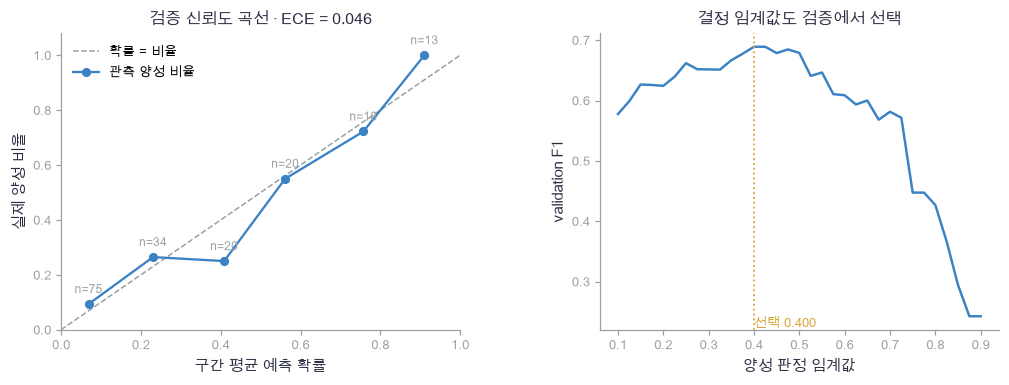

In [33]:
plot_reliability(bin_probabilities, bin_frequencies, bin_counts, ece, thresholds, threshold_f1, selected_threshold)

🔍 **확인** · 왼쪽 점들이 대각선에 가까울수록 확률이 실제 비율과 맞습니다. 관측이 적은 구간은 흔들립니다. 오른쪽에서 F1이 가장 큰 임계값을 검증에서 골랐습니다. 임계값도 설정이므로 test에서 고르지 않습니다.

### ✏️ 연습 5 · 확률 자체의 정확도

정답 `y` `(N,)`과 확률 `p` `(N,)`에서 Brier(확률과 정답의 제곱 차 평균)와 NLL(정답에 준 확률의 −log 평균)을 만드는 두 줄을 채우세요. 임계값으로 판정한 비율도, 순위도 아니라 확률 자체를 재는 두 지표입니다. 검사에는 임계값 .5의 판정이 같고 확신만 다른 확률 두 벌이 들어 있어, accuracy가 같아도 두 값이 달라지는 것을 봅니다.

In [34]:
def exercise_probability_metrics(y, p):
    """연습 5: 확률 자체의 정확도 두 가지. y: (N,) 0/1, p: (N,) 확률 → (brier: 숫자, nll: 숫자)."""
    assert y.shape == p.shape, "y와 p는 같은 길이의 (N,) 배열이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 확률과 정답의 제곱 차 평균 brier, 정답에 준 확률의 −log 평균 nll
    ### 힌트: 5절 손계산 셀의 brier·nll 두 식입니다. "정답에 준 확률"을 y와 p로 고르는 한 조각은 5절 코드 상자에 있습니다.
    raise NotImplementedError
    return brier, nll

In [35]:
def check_probability_metrics(candidate):
    """5절 손계산 관측 4개와, 판정은 같고 확신만 다른 확률 두 벌로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hm_y, hm_p, hm_metrics (5절 손계산 셀) · binary_metrics (5절)
    brier, nll = candidate(hm_y, hm_p)
    np.testing.assert_allclose(brier, .255)                                # 검산: 5절 손계산 (.01 + .64 + .36 + .01)/4
    np.testing.assert_allclose(nll, .6841124189)                           # 검산: −mean(log[.9, .2, .4, .9])
    np.testing.assert_allclose((brier, nll), (hm_metrics["brier"], hm_metrics["nll"]))   # 검산: 5절 손계산 셀의 값과 같음
    example_y = np.array([0, 0, 1, 1])
    mild_p, sharp_p = np.array([.2, .2, .8, .8]), np.array([.1, .1, .9, .9])   # 넷 다 맞히되 확신 .8 / 같은 판정, 확신 .9
    mild_brier, mild_nll = candidate(example_y, mild_p)
    sharp_brier, sharp_nll = candidate(example_y, sharp_p)
    np.testing.assert_allclose((mild_brier, mild_nll), (.04, -np.log(.8)))     # 검산: 0.2² 평균, −log .8
    np.testing.assert_allclose((sharp_brier, sharp_nll), (.01, -np.log(.9)))   # 검산: 0.1² 평균, −log .9
    assert sharp_brier < mild_brier and sharp_nll < mild_nll, "정확도가 같아도 맞는 확신이 커지면 Brier·NLL은 작아져야 합니다"
    reference = binary_metrics(example_y, sharp_p)
    np.testing.assert_allclose((sharp_brier, sharp_nll), (reference["brier"], reference["nll"]))   # 검산: 5절 binary_metrics와 같음
    print("Brier·NLL: 손계산과 일치합니다.")

run_check(check_probability_metrics, exercise_probability_metrics, hint="brier = np.mean((p - y) ** 2); nll = -np.mean(np.log(np.where(y == 1, p, 1 - p)))")

☐ exercise_probability_metrics: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: brier = np.mean((p - y) ** 2); nll = -np.mean(np.log(np.where(y == 1, p, 1 - p)))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
brier = np.mean((p - y) ** 2)
nll = -np.mean(np.log(np.where(y == 1, p, 1 - p)))
```

</details>

## 🔍 6. 선택을 고정하고 test에서 보고하기

지금까지 train은 파라미터·전처리에, validation은 $\lambda$·epoch·임계값 선택에 사용했습니다.
이제 그 선택을 고정하고 test 관측의 결과를 계산합니다.
seed별 표준편차는 **같은 데이터 분할에서 학습 무작위성에 따른 변동**을 요약합니다.
새 데이터 표본으로 바뀔 때의 불확실성은 데이터 재표집·여러 분할·bootstrap 등으로 별도 추정할 수 있습니다.

앞에서 임계값을 고른 대상은 세 실행의 평균 확률입니다. test에서도 그 평균 확률의 결과를 보고하고,
개별 seed의 수치는 공통 임계값 아래에서 학습 변동을 읽는 데 사용합니다.

> **코드**
>
> - `np.mean(test_probabilities, axis=0)`: 세 실행의 확률 배열을 쌓아 관측마다 평균낸 앙상블 확률.
> - `seed_nll.std(ddof=1)`: 표본 표준편차(분모 n − 1). seed 세 개의 학습 변동 크기입니다.
> - `for seed, run, metrics in zip(seeds, selected_runs, test_results)`: seed·실행·지표를 짝지어 한 줄씩 출력.
> - `changed_X[:, column] = changed_X[permutation, column]`: 한 열만 행 순서를 섞어 그 특성과 라벨의 관계를 끊습니다.

In [36]:
# 쓰는 것: raw_X, raw_y, test_index, train_mean, train_scale, seeds, selected_runs (4절 실험 셀) · transform (2절) · sigmoid (3절) · binary_metrics (5절) · selected_threshold (5절 calibration 셀)
X_test, y_test = transform(raw_X[test_index], train_mean, train_scale), raw_y[test_index]   # (180, 8), (180,): test에도 train의 통계
test_probabilities = [sigmoid(X_test @ run['w']+run['b']) for run in selected_runs]          # seed마다 test 확률
test_results = [binary_metrics(y_test, p, selected_threshold) for p in test_probabilities]   # 고정한 임계값으로
ensemble_probability = np.mean(test_probabilities, axis=0)  # (180,): 세 실행 평균 확률
ensemble_result = binary_metrics(y_test, ensemble_probability, selected_threshold)
for seed, run, metrics in zip(seeds, selected_runs, test_results):
    print(f"seed={seed}, epoch={run['epoch']}, test NLL={metrics['nll']:.6f}, accuracy={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}")
seed_nll = np.array([metrics['nll'] for metrics in test_results])   # (3,): seed별 test NLL
print('seed NLL 평균 / 표본 표준편차:', seed_nll.mean(), seed_nll.std(ddof=1))
print('세 실행 평균 확률 test:', {k:v for k,v in ensemble_result.items() if k != 'confusion'})

seed=1, epoch=89, test NLL=0.429953, accuracy=0.7722, F1=0.6095, AUC=0.8319
seed=2, epoch=58, test NLL=0.429226, accuracy=0.7778, F1=0.6154, AUC=0.8322
seed=3, epoch=48, test NLL=0.429568, accuracy=0.7833, F1=0.6355, AUC=0.8309
seed NLL 평균 / 표본 표준편차: 0.4295823305222184 0.0003638927795711383
세 실행 평균 확률 test: {'accuracy': np.float64(0.7722222222222223), 'precision': np.float64(0.5245901639344263), 'recall': np.float64(0.7272727272727273), 'f1': np.float64(0.6095238095238096), 'nll': np.float64(0.4294734341320058), 'brier': np.float64(0.14156076477094362), 'auc': np.float64(0.8322192513368984)}


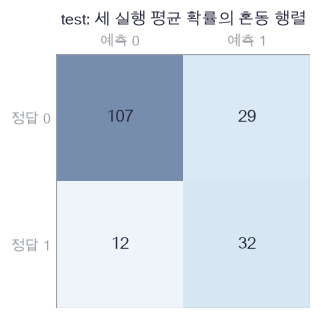

In [37]:
plot_confusion(ensemble_result["confusion"], "test: 세 실행 평균 확률의 혼동 행렬")

🔍 **확인** · test 결과는 한 번만 계산해 보고합니다. seed 세 개의 NLL 표준편차가 학습 무작위성의 크기이고, 이 값보다 작은 차이로 조건의 우열을 말하지 않습니다.

### 🔍 조건을 바꾸는 실험은 무엇을 측정하나요?

학습한 모델을 그대로 두고 validation의 첫 번째 특성만 섞으면 예측이 그 특성에 얼마나 의존하는지 살펴볼 수 있습니다.
여기서는 앞의 두 특성만 라벨 생성에 쓰였으므로, 첫 번째 특성과 여덟 번째 잡음 특성을 비교합니다.
이 **순열 실험**은 모델을 재학습하는 feature 제거 실험과 구분해 기록합니다.
분포 변화에서는 입력 관계 자체가 달라질 수 있으므로 원래 validation과 변화된 입력의 점수를 함께 읽습니다.

In [38]:
# 쓰는 것: X_valid, y_valid (4절 실험 셀) · reference_run, ordinary_metrics (5절 확신 셀) · sigmoid (3절) · binary_metrics (5절)
permutation_rng = np.random.default_rng(159)
permutation = permutation_rng.permutation(len(y_valid))     # (180,): 행을 섞을 순서
permuted_nll = {}                                           # 특성 번호 → 섞은 뒤의 NLL
for column in [0, 7]:                                       # 라벨에 쓰인 특성 0과 잡음 특성 7
    changed_X = X_valid.copy()
    changed_X[:, column] = changed_X[permutation, column]   # 그 열만 섞음
    changed_p = sigmoid(changed_X @ reference_run['w'] + reference_run['b'])   # 학습한 모델 그대로
    permuted_nll[column] = binary_metrics(y_valid, changed_p)['nll']
print('원래 validation NLL:', ordinary_metrics['nll'], '특성별 순열 NLL:', permuted_nll)

원래 validation NLL: 0.4434677231510092 특성별 순열 NLL: {0: np.float64(0.6937559796926075), 7: np.float64(0.44775356397494714)}


🔍 **확인** · 라벨에 쓰인 첫 특성을 섞으면 NLL이 크게 오르고, 잡음 특성을 섞으면 거의 변하지 않습니다.

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 사람 단위 분할 (1절)

사람 ID `group_ids` $(N,)$와 train에 둘 사람 목록 `train_group_set`에서 train·validation 행 인덱스를 만드는 두 줄을 채우세요.

In [39]:
def exercise_group_split(group_ids, train_group_set):
    """연습 A: 사람 단위 분할. group_ids: (N,) 사람 ID, train_group_set: train에 둘 사람 목록 → (train_idx, valid_idx: 행 번호 배열)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: train_idx = 사람이 train 목록에 있는 행 번호, valid_idx = 그 밖의 행 번호
    ### 힌트: np.isin(group_ids, train_group_set) 과 np.isin(..., invert=True), np.flatnonzero(...)
    raise NotImplementedError
    return train_idx, valid_idx

In [40]:
def check_group_split(candidate):
    """1절의 분할과 같은지, 겹침·빠짐이 없는지 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: group_ids, train_group_set, group_train, group_valid (1절 검산 셀)
    tr, va = candidate(group_ids, train_group_set)
    np.testing.assert_array_equal(tr, group_train)                                                    # 검산: 1절과 같은 train 행
    np.testing.assert_array_equal(va, group_valid)                                                    # 검산: 같은 validation 행
    assert len(np.intersect1d(group_ids[tr], group_ids[va])) == 0, "겹치는 사람이 없어야 합니다"
    assert len(tr) + len(va) == len(group_ids), "모든 행이 한쪽에 들어가야 합니다"
    print("사람 단위 분할: 1절과 일치하고 겹치는 사람이 없습니다.")

run_check(check_group_split, exercise_group_split, hint="train_idx = np.flatnonzero(np.isin(group_ids, train_group_set)); valid_idx = np.flatnonzero(np.isin(group_ids, train_group_set, invert=True))")

☐ exercise_group_split: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: train_idx = np.flatnonzero(np.isin(group_ids, train_group_set)); valid_idx = np.flatnonzero(np.isin(group_ids, train_group_set, invert=True))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
train_idx = np.flatnonzero(np.isin(group_ids, train_group_set))
valid_idx = np.flatnonzero(np.isin(group_ids, train_group_set, invert=True))
```

</details>

### ✏️ 연습 B · 표준화 통계의 fit (2절)

학습 입력 `X` $(N,D)$에서 열별 평균과 표준편차를 만드는 두 줄을 채우세요. 표준편차가 0에 가까운 상수 열은 1로 둡니다.

In [41]:
def exercise_fit_standardizer(X):
    """연습 B: 표준화 통계의 fit. X: (N, D) → (mean: (D,), scale: (D,), 상수 열은 1)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: mean = 열별 평균 (D,), scale = 열별 표준편차인데 1e-12 보다 작으면 1
    ### 힌트: X.std(axis=0), np.where(scale < 1e-12, 1., scale)
    raise NotImplementedError
    return mean, scale

In [42]:
def check_fit_standardizer(candidate):
    """2절 손계산(상수 열 포함)과 실험 데이터의 본문 fit_standardizer로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: small_train (2절 검산 셀) · raw_X, train_index, train_mean, train_scale (4절 실험 셀) · transform (2절)
    m_a, s_a = candidate(small_train)
    np.testing.assert_allclose(m_a, [3., 4.])                                                        # 검산: 2절 손계산 평균
    np.testing.assert_allclose(s_a, [np.sqrt(8 / 3), 1.])                                            # 검산: 표준편차, 상수 열은 1
    m_b, s_b = candidate(raw_X[train_index])
    np.testing.assert_allclose(m_b, train_mean)                                                      # 검산: 본문 fit_standardizer 와 같음
    np.testing.assert_allclose(s_b, train_scale)                                                     # 검산: 표준편차도 같음
    np.testing.assert_allclose(transform(raw_X[train_index], m_b, s_b).std(axis=0), 1.)              # 검산: 변환한 학습 데이터는 열마다 표준편차 1
    print("표준화 fit: 손계산·fit_standardizer 와 일치합니다.")

run_check(check_fit_standardizer, exercise_fit_standardizer, hint="mean = X.mean(axis=0); scale = np.where(X.std(axis=0) < 1e-12, 1., X.std(axis=0))")

☐ exercise_fit_standardizer: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: mean = X.mean(axis=0); scale = np.where(X.std(axis=0) < 1e-12, 1., X.std(axis=0))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
mean = X.mean(axis=0)
scale = np.where(X.std(axis=0) < 1e-12, 1., X.std(axis=0))
```

</details>

### ✏️ 연습 C · 로지스틱 회귀의 기울기 (3절)

`X`, `y`, `w`, `b`, `l2`에서 logit 기울기 `g`와 가중치 기울기 `dw`를 만드는 두 줄을 채우세요. `db`는 써 두었습니다.

In [43]:
def exercise_logistic_grads(X, y, w, b, l2=0.):
    """연습 C: 로지스틱 회귀의 기울기. X: (N, D), y: (N,), w: (D,), b: 숫자 → (dw: (D,), db: 숫자)."""
    logits = X @ w + b                                      # (N,)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: g = (sigmoid(logits) − y) / N, dw = X 의 전치 @ g + l2 · w
    ### 힌트: 3절의 g 와 dw 식입니다. sigmoid 는 3절에 있습니다.
    raise NotImplementedError
    db = g.sum()
    return dw, db

In [44]:
def check_logistic_grads(candidate):
    """본문 logistic_objective와 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: X_check, y_check, w_check, b_check (3절 검산 셀) · logistic_objective (3절)
    dw_a, db_a = candidate(X_check, y_check, w_check, b_check, l2=.2)
    _, _, dw_ref, db_ref = logistic_objective(X_check, y_check, w_check, b_check, l2=.2)
    np.testing.assert_allclose(dw_a, dw_ref)                                                         # 검산: 3절 함수의 dw
    np.testing.assert_allclose(db_a, db_ref)                                                         # 검산: db

    def scalar():
        """검사기용: 목적값 J."""
        return logistic_objective(X_check, y_check, w_check, b_check, l2=.2)[0]

    numeric = numerical_gradient(scalar, w_check)
    assert rel_error(dw_a, numeric) < 1e-7, "dw가 중심차분과 1e−7 안에서 같아야 합니다"
    print("로지스틱 기울기: logistic_objective·중심차분과 일치합니다.")

run_check(check_logistic_grads, exercise_logistic_grads, hint="g = (sigmoid(logits) - y) / len(y); dw = X.T @ g + l2 * w")

☐ exercise_logistic_grads: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: g = (sigmoid(logits) - y) / len(y); dw = X.T @ g + l2 * w


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
g = (sigmoid(logits) - y) / len(y)
dw = X.T @ g + l2 * w
```

</details>

### ✏️ 연습 D · 쌍 비교로 AUC (5절)

정답 `y`와 확률 `p`에서 모든 양성·음성 쌍의 점수 차로 AUC를 만드는 두 줄을 채우세요. 동점은 절반으로 셉니다.

In [45]:
def exercise_auc(y, p):
    """연습 D: 쌍 비교로 AUC. y: (N,) 0/1, p: (N,) 확률 → 숫자 하나 (동점은 절반)."""
    positives, negatives = p[y == 1], p[y == 0]             # 양성 점수, 음성 점수
    assert len(positives), "양성이 하나 이상 있어야 합니다"
    assert len(negatives), "음성이 하나 이상 있어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: differences = 양성 점수 − 음성 점수의 모든 쌍 (P, Q), auc = (차 > 0) + 0.5·(차 == 0) 의 평균
    ### 힌트: positives[:, None] - negatives[None, :]
    raise NotImplementedError
    return auc

In [46]:
def check_auc(candidate):
    """5절 손계산, 동점 규약, 본문 binary_metrics(검증·MNIST)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hm_y, hm_p (5절 손계산 셀) · y_valid (4절 실험 셀) · validation_p, ordinary_metrics (5절 확신 셀) · mnist_T (📎 데이터 셀) · mnist_p, mnist_metrics (5절 MNIST 셀)
    np.testing.assert_allclose(candidate(hm_y, hm_p), .75)                                                  # 검산: 5절 손계산
    np.testing.assert_allclose(candidate(np.array([0, 1]), np.array([.5, .5])), .5)                        # 검산: 동점은 0.5
    np.testing.assert_allclose(candidate(y_valid, validation_p), ordinary_metrics["auc"])                  # 검산: binary_metrics 와 같음 (검증)
    np.testing.assert_allclose(candidate(mnist_T, mnist_p), mnist_metrics["auc"])                          # 검산: MNIST에서도 같음
    print("AUC: 손계산·동점 규약·binary_metrics 와 일치합니다.")

run_check(check_auc, exercise_auc, hint="differences = positives[:, None] - negatives[None, :]; auc = np.mean((differences > 0) + .5 * (differences == 0))")

☐ exercise_auc: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: differences = positives[:, None] - negatives[None, :]; auc = np.mean((differences > 0) + .5 * (differences == 0))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
differences = positives[:, None] - negatives[None, :]
auc = np.mean((differences > 0) + .5 * (differences == 0))
```

</details>

### 🔍 완성 예제 · 같은 확률에서 지표 다시 만들기

아래 검사기는 후보 지표 함수를 손계산 관측·동점·양성 예측 0개·확률 0·1·한 클래스만 있는 경우에 넣어 봅니다. 본문의 `binary_metrics`로 통과시킨 뒤, 실험 정보를 결과와 함께 한곳에 기록합니다.
`raw_y` 생성식의 절편을 $-1.2$에서 $-2.5$로 바꾸고 **새 실험의 분할부터** 다시 실행하면 양성 비율·정확도·recall·선택 임계값이 어떻게 달라지는지 볼 수 있습니다.

In [47]:
def check_binary_metrics(candidate):
    """지표 함수 후보를 여덟 경우(손계산, 다른 임계값, 확률 0·1, 동점, precision ≠ recall, 한 클래스뿐)에 넣어 본문 binary_metrics와 비교합니다. 통과하면 문자열을 돌려줍니다."""
    # 쓰는 것: binary_metrics (5절)
    cases = [
        (np.array([0, 0, 1, 1]), np.array([.1, .8, .4, .9]), .5),
        (np.array([0, 1, 1, 0]), np.array([.5, .5, .2, .1]), .7),
        (np.array([0, 1]), np.array([0., 1.]), .5),
        (np.array([0, 1]), np.array([1., 0.]), .5),
        (np.array([0, 1]), np.array([.5, .5]), .5),  # 임계값과 같은 확률
        (np.array([1, 1, 1, 0]), np.array([.9, .4, .3, .2]), .5),  # precision과 recall이 다름
        (np.array([0, 0, 0]), np.array([.1, .2, .8]), .5),  # 한 클래스의 AUC 규약
        (np.array([1, 1]), np.array([.1, .2]), .5),
    ]
    for y, p, threshold in cases:
        actual = candidate(y.copy(), p.copy(), threshold)
        expected = binary_metrics(y, p, threshold)
        assert isinstance(actual, dict), "결과는 사전이어야 합니다"
        assert expected.keys() <= actual.keys(), "본문 함수의 키가 모두 있어야 합니다"
        for key, reference in expected.items():
            assert np.shape(actual[key]) == np.shape(reference), key
            np.testing.assert_allclose(actual[key], reference, atol=1e-12, err_msg=key)   # 검산: 지표마다 본문 함수와 같음
    return '통과: 혼동행렬·임계값·동점 순위·분모 규약·확률 지표'

In [48]:
# 쓰는 것: binary_metrics (5절) · l2_values, seeds, selected_l2, selected_runs (4절 실험 셀) · selected_threshold (5절 calibration 셀) · ensemble_result, seed_nll (6절 test 셀)
print(check_binary_metrics(binary_metrics))
# 재실행 후 기록할 실험 정보를 결과 값과 함께 한곳에 모읍니다.
experiment_record = {
    'data_seed': 151, 'split_seed': 152, 'train_validation_test_counts': [540, 180, 180],
    'l2_candidates': l2_values, 'training_seeds': seeds,
    'selected_l2': selected_l2, 'selected_epochs': [run['epoch'] for run in selected_runs],
    'selected_threshold': selected_threshold, 'selection_metric': 'validation BCE then ensemble validation F1',
    'test_ensemble_nll': ensemble_result['nll'], 'test_ensemble_f1': ensemble_result['f1'],
    'test_seed_nll_std': float(seed_nll.std(ddof=1)),
}
print(experiment_record)

통과: 혼동행렬·임계값·동점 순위·분모 규약·확률 지표
{'data_seed': 151, 'split_seed': 152, 'train_validation_test_counts': [540, 180, 180], 'l2_candidates': [0.0, 0.02, 0.2], 'training_seeds': [1, 2, 3], 'selected_l2': 0.0, 'selected_epochs': [89, 58, 48], 'selected_threshold': 0.4, 'selection_metric': 'validation BCE then ensemble validation F1', 'test_ensemble_nll': np.float64(0.4294734341320058), 'test_ensemble_f1': np.float64(0.6095238095238096), 'test_seed_nll_std': 0.0003638927795711383}


### ✏️ 준비도 질문 · 다섯 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- 새 사람·새 시점·새 문서 중 무엇을 예측하는지 정하고 분할 단위를 만들 수 있나요? → 1절
- 전처리 파라미터와 모델 파라미터가 어느 데이터에서 학습되는지 추적할 수 있나요? → 2절
- 작은 데이터 학습과 별도 validation 평가의 목적을 각각 설명할 수 있나요? → 3·4절
- accuracy·NLL·Brier·AUC가 같은 예측의 어떤 성질을 읽는지 손계산할 수 있나요? → 5절
- $\lambda$·epoch·임계값을 고정한 뒤 test 결과와 seed 변동을 기록할 수 있나요? → 4·6절

다음은 [전체 경로](../../docs/CURRICULUM.md)의 구조 조합 또는 Autoencoder 경로입니다.
새 모델에서도 이 실험 순서를 사용하며, 생성·표현·RL의 목적에 맞는 지표를 추가합니다.

📎 공식 참고: [scikit-learn의 데이터 누출과 전처리 안내](https://scikit-learn.org/stable/common_pitfalls.html),
[분류 확률 calibration 안내](https://scikit-learn.org/stable/modules/calibration.html).
이 노트북의 분할·학습·지표 계산은 NumPy로 본문에 구현했습니다.